In [1]:
### Head
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import homogeneity_completeness_v_measure

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load all CSV

In [3]:
def load_data(base_dir):
    df_list = []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.endswith(".csv"):
                file_path = os.path.join(root, file)
                df = pd.read_csv(file_path)
                df_list.append(df)
    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

base_dir = "/content/drive/MyDrive/captures/MAC_derand_lecture-dataset/lecture-dataset"
df = load_data(base_dir)

Preprocess the dataset by handling missing values, converting timestamps, and encoding categorical features.

In [4]:
def preprocess_data(df):
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], unit="s")
    # Handling missing values
    nan_percentage = (df.isna().sum() / len(df)) * 100
    col_drop = nan_percentage[nan_percentage > 50].index.tolist()
    df = df.drop(columns=col_drop)
    print(col_drop)
    return df

# Calculate the sum of NaN values in each column
nan_sum = df.isna().sum()
nan_percentage = (nan_sum / len(df)) * 100
print(nan_percentage)

df_preprocessed = preprocess_data(df)

Timestamp                     0.000000
MAC Address                   0.000000
Channel                       0.000000
DS Channel                    0.581395
HT Capabilities               0.020048
Extended Capabilities         0.020048
Vendor Specific Tags         18.905373
SSID                         91.439455
Supported Rates               0.000000
Extended Supported Rates      0.020048
VHT Capabilities            100.000000
HE Capabilities              81.295108
Length                        0.000000
Label                         0.000000
dtype: float64
['SSID', 'VHT Capabilities', 'HE Capabilities']


Identify features with a low number of unique values.

In [5]:
def select_features(df):
    unique_counts = df.nunique()
    selected_features = [col for col in unique_counts.index if unique_counts[col] < 20]
    print(selected_features)
    return selected_features

unique_elem = df_preprocessed.nunique()
print(unique_elem)
selected_features = select_features(df_preprocessed)

Timestamp                   4988
MAC Address                  718
Channel                        3
DS Channel                    13
HT Capabilities                8
Extended Capabilities          7
Vendor Specific Tags           5
Supported Rates                4
Extended Supported Rates       2
Length                        16
Label                          7
dtype: int64
['Channel', 'DS Channel', 'HT Capabilities', 'Extended Capabilities', 'Vendor Specific Tags', 'Supported Rates', 'Extended Supported Rates', 'Length', 'Label']


Apply Label Encoding to categorical features.

In [6]:
def encode_features(df, features):
    df_encoded = df.copy()
    label_encoder = LabelEncoder()

    encoded_features = []

    for col in features:
        if col not in ["Length", "Channel", "DS Channel", "Label"]:  # Skip numerical and label columns
            df_encoded[col] = label_encoder.fit_transform(df_encoded[col].astype(str))
            encoded_features.append(col)

    df_encoded[encoded_features] = df_encoded[encoded_features].astype(float)

    return df_encoded

df_encoded = encode_features(df_preprocessed, selected_features)
display(df_encoded)

,Timestamp,MAC Address,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,Supported Rates,Extended Supported Rates,Length,Label
0,2021-07-08 08:07:27.307995081,7a:e3:17:f9:50:df,1,1.0,1.0,4.0,0.0,0.0,0.0,121,SamsungJ6_K
1,2021-07-08 08:07:27.308015108,7a:e3:17:f9:50:df,11,1.0,1.0,4.0,0.0,0.0,0.0,121,SamsungJ6_K
2,2021-07-08 08:07:27.318708897,7a:e3:17:f9:50:df,11,1.0,1.0,4.0,0.0,0.0,0.0,121,SamsungJ6_K
3,2021-07-08 08:07:27.318726063,7a:e3:17:f9:50:df,1,1.0,1.0,4.0,0.0,0.0,0.0,121,SamsungJ6_K
4,2021-07-08 08:07:27.397764921,7a:e3:17:f9:50:df,11,2.0,1.0,4.0,0.0,0.0,0.0,121,SamsungJ6_K
...,...,...,...,...,...,...,...,...,...,...,...
4983,2021-05-31 16:00:46.843775034,22:45:43:e4:c8:fd,1,1.0,2.0,2.0,1.0,0.0,0.0,144,iPhone6_N
4984,2021-05-31 16:00:46.950447083,22:45:43:e4:c8:fd,6,4.0,2.0,2.0,1.0,0.0,0.0,156,iPhone6_N
4985,2021-05-31 16:00:46.970405102,22:45:43:e4:c8:fd,6,4.0,2.0,2.0,1.0,0.0,0.0,156,iPhone6_N
4986,2021-05-31 16:00:46.998914957,22:45:43:e4:c8:fd,6,5.0,2.0,2.0,1.0,0.0,0.0,156,iPhone6_N


Group data by MAC Address and extract the first occurrence.

In [7]:
def extract_burst_df(df):
    burst_df = df.drop(columns=["Timestamp"])
    burst_df = burst_df.groupby("MAC Address").first().reset_index()
    label_counts = burst_df["Label"].value_counts()
    print(label_counts)
    return burst_df

burst_df = extract_burst_df(df_encoded)
# Display results
display(burst_df)
label_counts = burst_df["Label"].value_counts()
print(label_counts)

Label
iPhone11-C_a      334
iPhone12_W        147
HuaweiHonor9_R     89
iPhone6_N          57
iPhoneXR-U         36
S21Ultra-M_a       28
SamsungJ6_K        27
Name: count, dtype: int64


,MAC Address,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,Supported Rates,Extended Supported Rates,Length,Label
0,00:0f:00:6a:68:8b,1,NaN,8.0,7.0,5.0,3.0,2.0,76,SamsungJ6_K
1,00:78:b5:8a:40:84,11,10.0,6.0,5.0,5.0,1.0,0.0,132,iPhone11-C_a
2,00:c6:7e:33:8c:62,11,11.0,6.0,5.0,5.0,1.0,0.0,132,iPhone11-C_a
3,00:cb:d6:50:04:2c,11,10.0,6.0,5.0,5.0,1.0,0.0,132,iPhone11-C_a
4,01:31:03:f5:11:4b,11,11.0,6.0,5.0,5.0,1.0,0.0,132,iPhone11-C_a
...,...,...,...,...,...,...,...,...,...,...
713,fe:7b:b8:60:08:c7,11,13.0,6.0,5.0,5.0,1.0,0.0,132,iPhone11-C_a
714,fe:9d:55:a5:9f:4a,1,1.0,6.0,5.0,5.0,1.0,0.0,143,iPhone12_W
715,fe:d8:06:8a:6a:09,1,1.0,3.0,3.0,5.0,0.0,0.0,113,iPhoneXR-U
716,fe:f9:fc:fb:83:9e,6,6.0,2.0,2.0,1.0,0.0,0.0,156,iPhone6_N


Label
iPhone11-C_a      334
iPhone12_W        147
HuaweiHonor9_R     89
iPhone6_N          57
iPhoneXR-U         36
S21Ultra-M_a       28
SamsungJ6_K        27
Name: count, dtype: int64


Plot a heatmap for the relationship between two categorical columns.

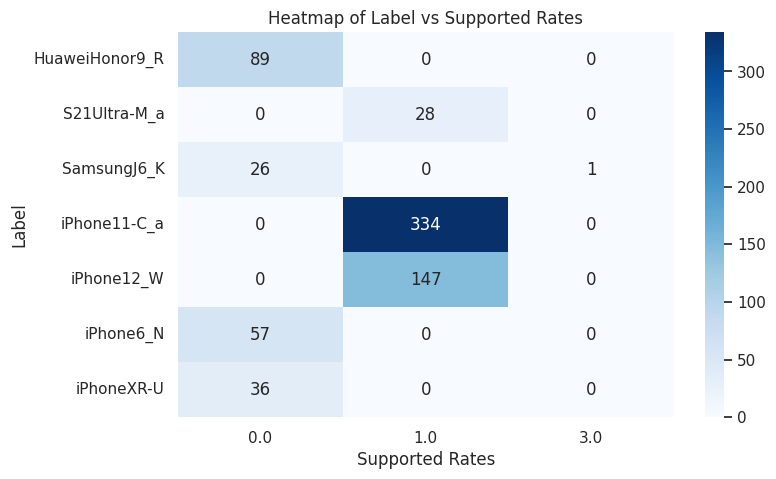

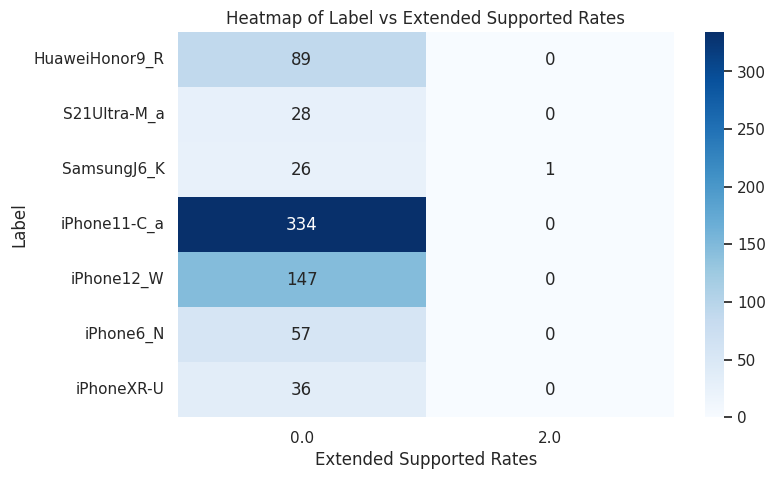

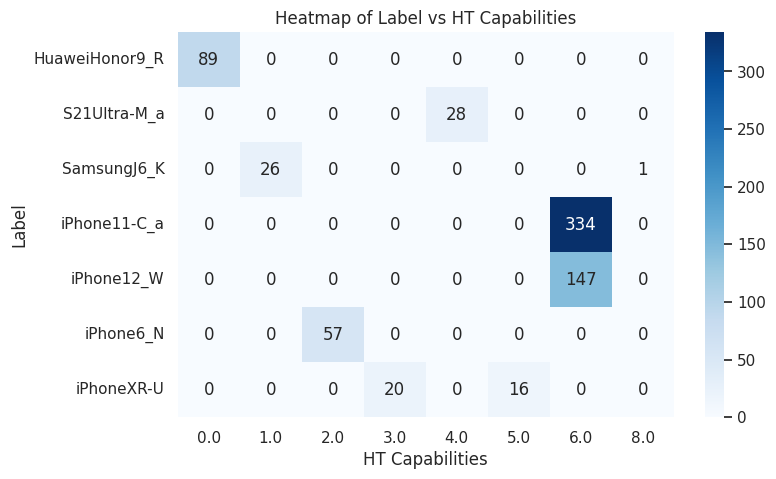

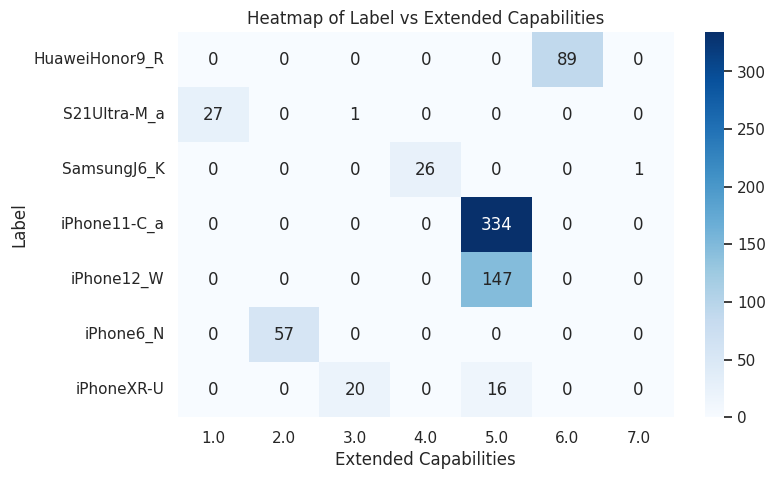

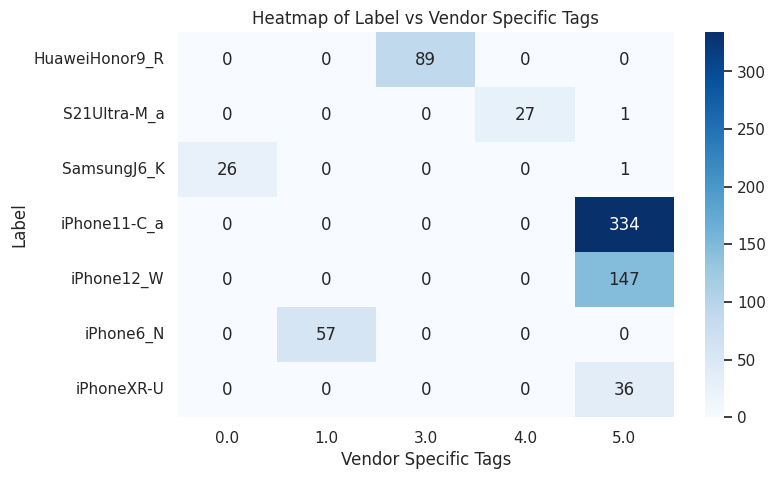

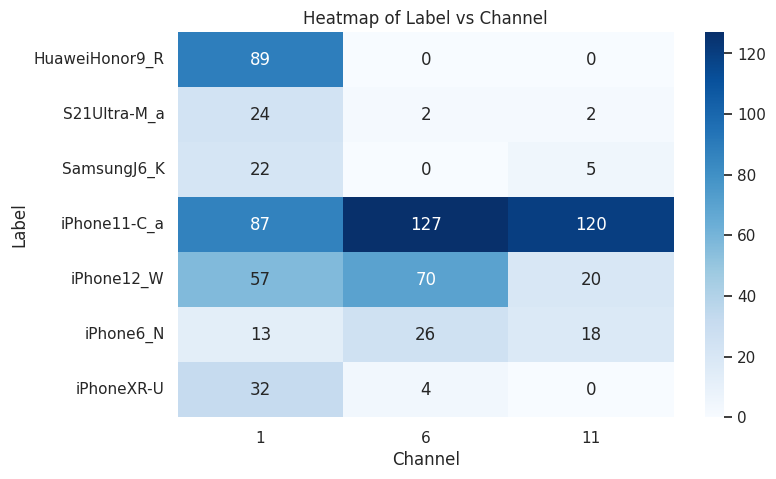

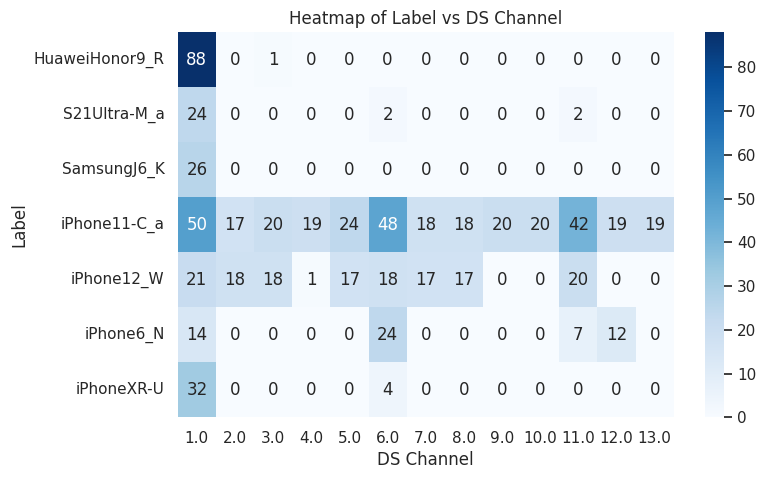

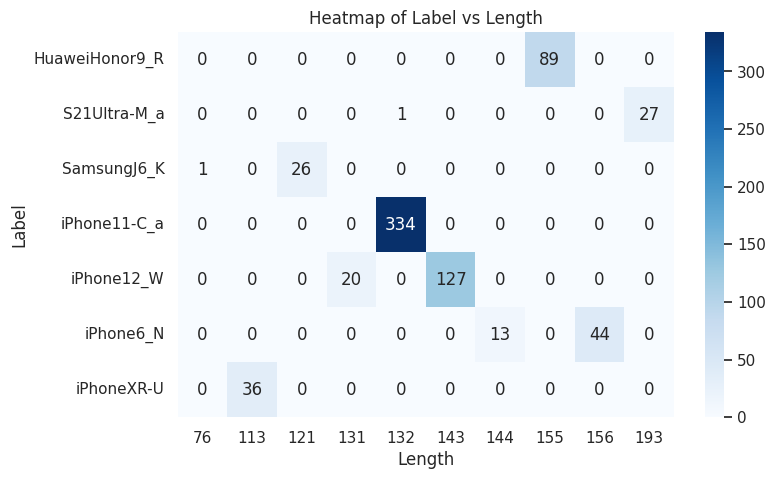

In [8]:
def plot_heatmap(df, column1, column2, colormap="Blues"):
    crosstab = pd.crosstab(df[column1], df[column2])
    sns.set_theme(style="whitegrid", font_scale=1)
    plt.figure(figsize=(8, 5))
    sns.heatmap(crosstab, annot=True, fmt="d", cmap=colormap)
    plt.title(f"Heatmap of {column1} vs {column2}")
    plt.xlabel(column2)
    plt.ylabel(column1)
    plt.show()

# Plot heatmaps
columns_to_plot = ["Supported Rates", "Extended Supported Rates", "HT Capabilities",
                   "Extended Capabilities", "Vendor Specific Tags", "Channel", "DS Channel", "Length"]
for col in columns_to_plot:
    plot_heatmap(burst_df, "Label", col)

Point 1-2

In [ ]:
def assign_clusters(burst_df, N):
    # Record each Cluster ID
    label_cluster = []
    cluster_count = 0
    cluster_map = {}  # Saved Cluster ID
    feature_columns = [
        "HT Capabilities", "Extended Capabilities",
        "Vendor Specific Tags", "Supported Rates", "Length", "Extended Supported Rates"
    ]

    for index, row in burst_df.iterrows():
        best_match_idx = None
        best_match_count = 0

        # Find the best match
        for prev_idx, prev_row in cluster_map.items():
            match_count = sum(row[feature] == prev_row[feature] for feature in feature_columns)

            if match_count > best_match_count:
                best_match_count = match_count
                best_match_idx = prev_idx

        # >=N, assign the same Cluster ID
        if best_match_count >= N and best_match_idx is not None:
            # Find the corresponding element of best_match_idx in label_cluster
            match_entry = next((entry for entry in label_cluster if entry[0] == best_match_idx), None)
            if match_entry:
                cluster_id = match_entry[2]  # Use the cluster_id from the found element
            else:
                cluster_id = cluster_count
                cluster_count += 1
        else:  # <N, assign a new Cluster ID
            cluster_id = cluster_count
            cluster_count += 1

        label_cluster.append((index, row['Label'], cluster_id))
        cluster_map[index] = row

    df_result = pd.DataFrame(label_cluster, columns=["Index", "Label", "Cluster ID"])
    num_clusters = df_result["Cluster ID"].nunique()
    return df_result, num_clusters

Threshold = 1
V-measure: 0.0
Number of clusters: 1
Number of labels: 7
Error: 6
Threshold = 2
V-measure: 0.5280241038664261
Number of clusters: 3
Number of labels: 7
Error: 4
Threshold = 3
V-measure: 0.7523365648822261
Number of clusters: 6
Number of labels: 7
Error: 1
Threshold = 4
V-measure: 0.8373805865065693
Number of clusters: 7
Number of labels: 7
Error: 0
Threshold = 5
V-measure: 0.8310381281614911
Number of clusters: 9
Number of labels: 7
Error: 2
Threshold = 6
V-measure: 0.9475759815226307
Number of clusters: 12
Number of labels: 7
Error: 5


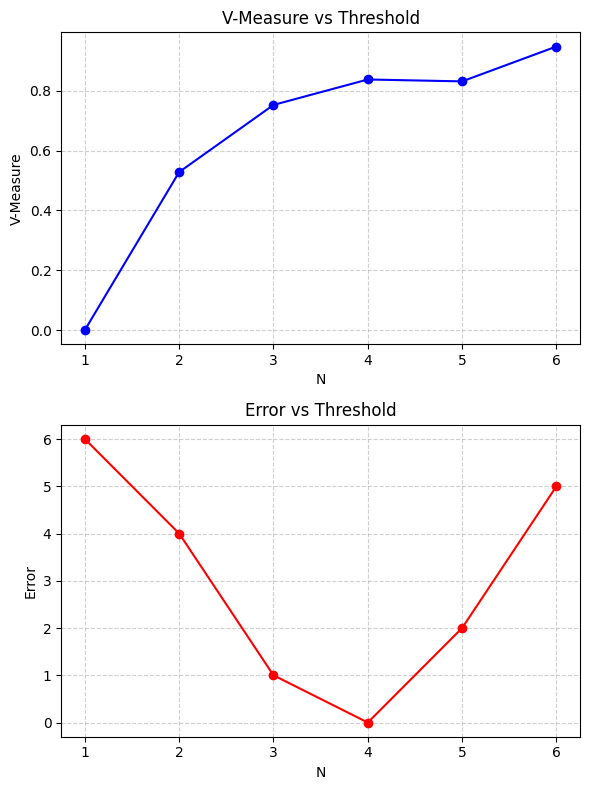

In [ ]:
# main
v_measure_scores = []
error_scores = []
N_values = range(1, 7)

for N in N_values:
    clustered_df, num_clusters = assign_clusters(burst_df, N)
    v_measure = homogeneity_completeness_v_measure(clustered_df["Label"], clustered_df["Cluster ID"])[2]
    error = abs(len(clustered_df["Cluster ID"].unique()) - len(clustered_df["Label"].unique()))
    print(f"Threshold = {N}")
    print(f"V-measure: {v_measure}")
    print(f"Number of clusters: {num_clusters}")
    print(f"Number of labels: {len(clustered_df['Label'].unique())}")
    print(f"Error: {error}")
    v_measure_scores.append(v_measure)
    error_scores.append(error)

# plot
plt.figure(figsize=(6, 8))
plt.style.use('default')

# V-Measure
plt.subplot(2, 1, 1)
plt.plot(N_values, v_measure_scores, marker='o', linestyle='-', color='blue')
plt.xticks(N_values)
plt.xlabel("N")
plt.ylabel("V-Measure")
plt.title("V-Measure vs Threshold")
plt.grid(True, linestyle='--', alpha=0.6)

# Error
plt.subplot(2, 1, 2)
plt.plot(N_values, error_scores, marker='o', linestyle='-', color='red')
plt.xticks(N_values)
plt.xlabel("N")
plt.ylabel("Error")
plt.title("Error vs Threshold")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# get max V-Measure and N
max_v_measure = max(v_measure_scores)
best_N = N_values[v_measure_scores.index(max_v_measure)]

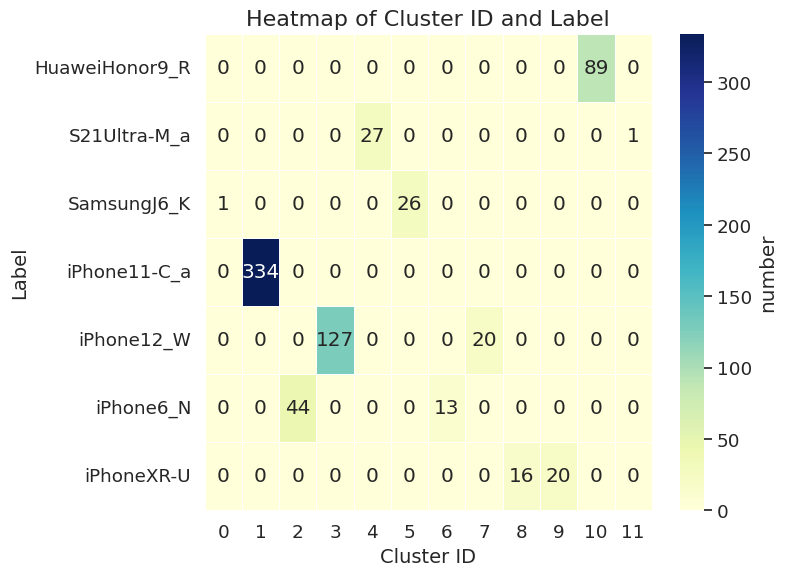

In [ ]:
def plot_heatmap(clustered_df):
    cross_tab = pd.crosstab(clustered_df['Label'], clustered_df['Cluster ID'])

    plt.figure(figsize=(8, 6))
    sns.set(font_scale=1.2)

    heatmap = sns.heatmap(cross_tab, annot=True, cmap="YlGnBu", fmt="d",
                        linewidths=.5, cbar_kws={'label': 'number'})

    plt.title('Heatmap of Cluster ID and Label', fontsize=16)
    plt.xlabel('Cluster ID', fontsize=14)
    plt.ylabel('Label', fontsize=14)

    plt.tight_layout()
    plt.show()

plot_heatmap(clustered_df)

Point 3-4

In [9]:
base_dir_2 = "/content/drive/MyDrive/captures/MAC_derand_challenge-dataset/challenge-dataset"
df_2 = load_data(base_dir_2)

nan_sum = df_2.isna().sum()
nan_percentage = (nan_sum / len(df_2)) * 100
print(nan_percentage)

df_preprocessed_2 = preprocess_data(df_2)
unique_elem = df_preprocessed.nunique()

selected_features_2 = select_features(df_preprocessed_2)
df_encoded_2 = encode_features(df_preprocessed_2, selected_features_2)
burst_df_2 = extract_burst_df(df_encoded_2)

display(burst_df_2)

Timestamp                    0.000000
MAC Address                  0.000000
Channel                      0.000000
DS Channel                   0.000000
HT Capabilities              3.558577
Extended Capabilities        3.558577
Vendor Specific Tags        29.814741
SSID                        94.695455
Supported Rates              0.000000
Extended Supported Rates     0.000000
VHT Capabilities            81.034253
HE Capabilities             51.219512
Length                       0.000000
Label                        0.000000
dtype: float64
['SSID', 'VHT Capabilities', 'HE Capabilities']
['Channel', 'DS Channel', 'HT Capabilities', 'Extended Capabilities', 'Vendor Specific Tags', 'Supported Rates', 'Extended Supported Rates', 'Length', 'Label']
Label
iPhone12_W             1206
XiaomiRedmiNote9S_T     138
HuaweiHonor9_R           89
SamsungS7_I              38
GooglePixel3A_V          23
SamsungM31_A             15
Name: count, dtype: int64


,MAC Address,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,Supported Rates,Extended Supported Rates,Length,Label
0,02:00:00:00:00:00,1,1,1.0,2.0,0.0,1.0,1.0,123,SamsungM31_A
1,02:02:70:30:b6:43,1,3,2.0,3.0,7.0,2.0,0.0,143,iPhone12_W
2,02:0b:5b:9e:41:54,1,1,3.0,4.0,2.0,0.0,0.0,154,SamsungS7_I
3,02:0b:72:cb:7d:eb,1,1,3.0,4.0,2.0,0.0,0.0,154,SamsungS7_I
4,02:0c:01:7e:50:d6,1,1,3.0,4.0,2.0,0.0,0.0,154,SamsungS7_I
...,...,...,...,...,...,...,...,...,...,...
1504,fe:c5:50:16:eb:8c,11,11,2.0,3.0,7.0,2.0,0.0,131,iPhone12_W
1505,fe:ed:a5:45:e8:b9,11,11,4.0,1.0,1.0,0.0,0.0,143,XiaomiRedmiNote9S_T
1506,fe:f5:97:dd:58:86,6,8,2.0,3.0,7.0,2.0,0.0,143,iPhone12_W
1507,fe:f9:ac:47:0d:b7,11,11,2.0,3.0,7.0,2.0,0.0,131,iPhone12_W


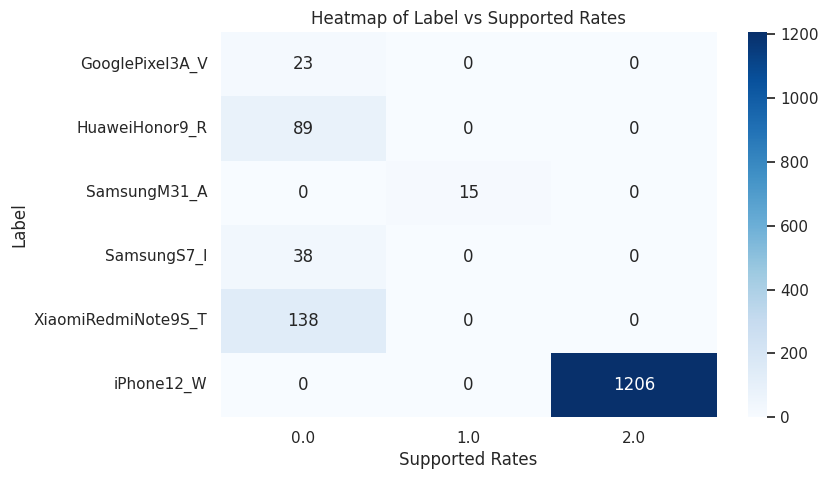

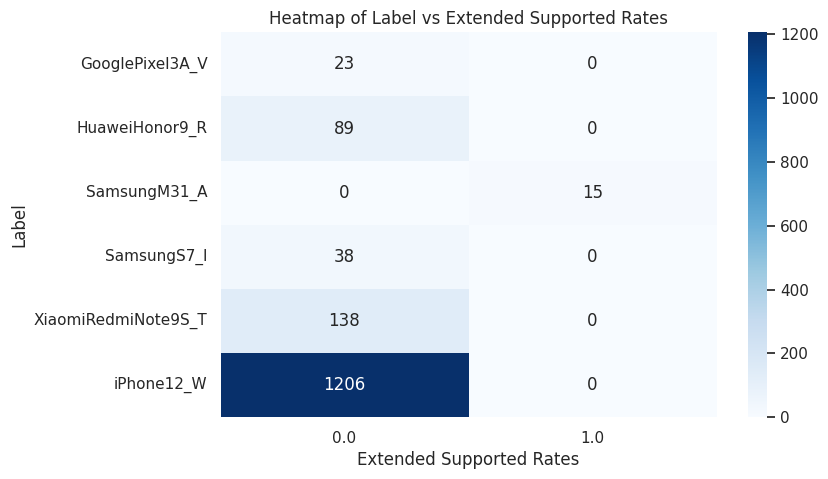

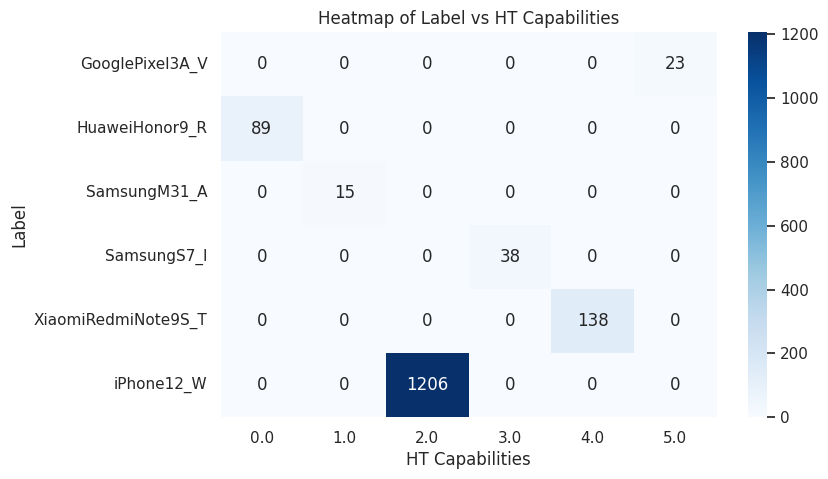

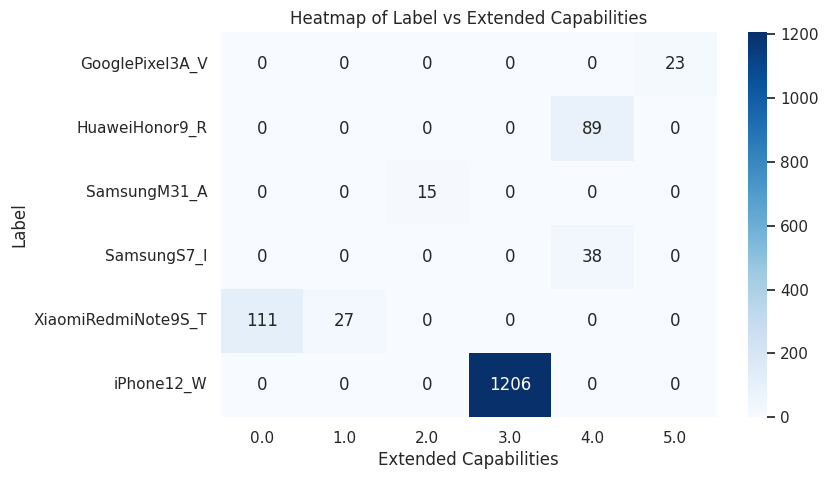

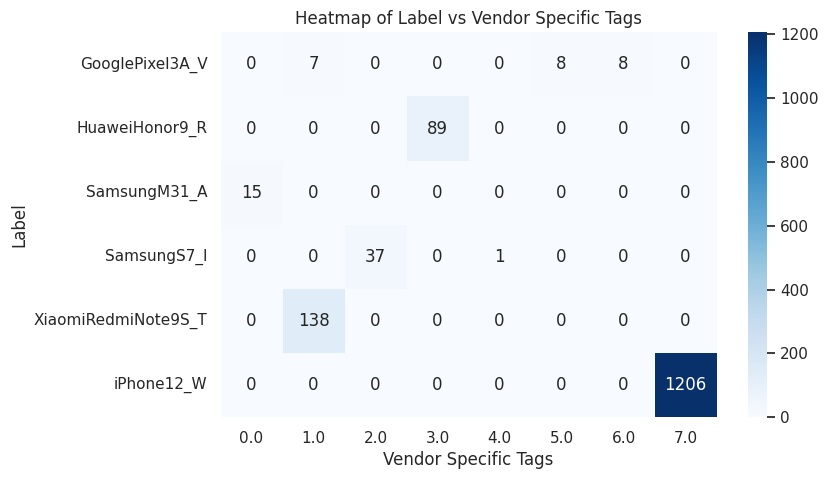

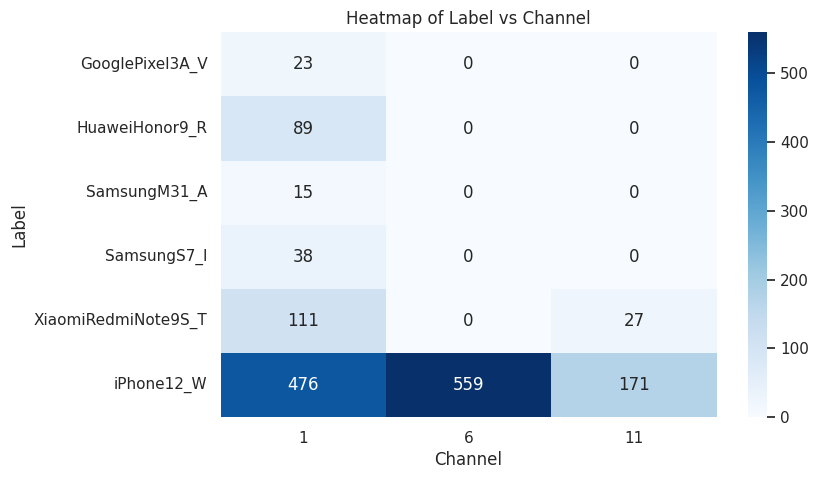

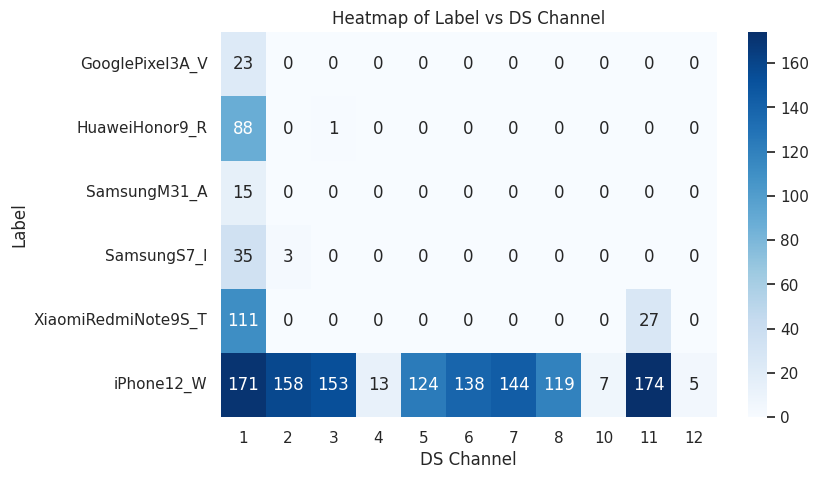

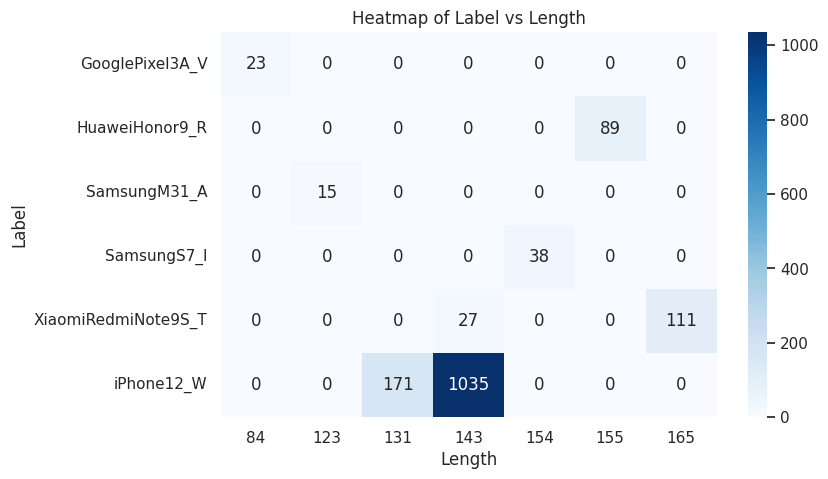

In [ ]:
# Plot heatmaps
columns_to_plot = ["Supported Rates", "Extended Supported Rates", "HT Capabilities",
                   "Extended Capabilities", "Vendor Specific Tags", "Channel", "DS Channel", "Length"]
for col in columns_to_plot:
    plot_heatmap(burst_df_2, "Label", col)

Iteration 1
V-Measure: 0.3063649074109363
Error: 3
Iteration 2
V-Measure: 1.0
Error: 0
Iteration 3
V-Measure: 0.7303330321970501
Error: 3
Iteration 4
V-Measure: 0.8184775901001883
Error: 2
Iteration 5
V-Measure: 0.9710281614894831
Error: 1
K = 2
Average V-Measure: 0.7652407382395315
Average Error: 1.8
Iteration 1
V-Measure: 0.8908980342147231
Error: 2
Iteration 2
V-Measure: 0.6865146150849601
Error: 3
Iteration 3
V-Measure: 0.6297363052294858
Error: 3
Iteration 4
V-Measure: 0.6666241125408685
Error: 2
Iteration 5
V-Measure: 0.7151700462365949
Error: 3
K = 3
Average V-Measure: 0.7177886226613264
Average Error: 2.6
Iteration 1
V-Measure: 0.897657237927596
Error: 2
Iteration 2
V-Measure: 0.7545922466413679
Error: 2
Iteration 3
V-Measure: 0.712926604935579
Error: 3
Iteration 4
V-Measure: 0.7138014246086728
Error: 5
Iteration 5
V-Measure: 0.5840688254516075
Error: 4
K = 4
Average V-Measure: 0.7326092679129645
Average Error: 3.2
Iteration 1
V-Measure: 0.7861184026252933
Error: 3
Iteration 2


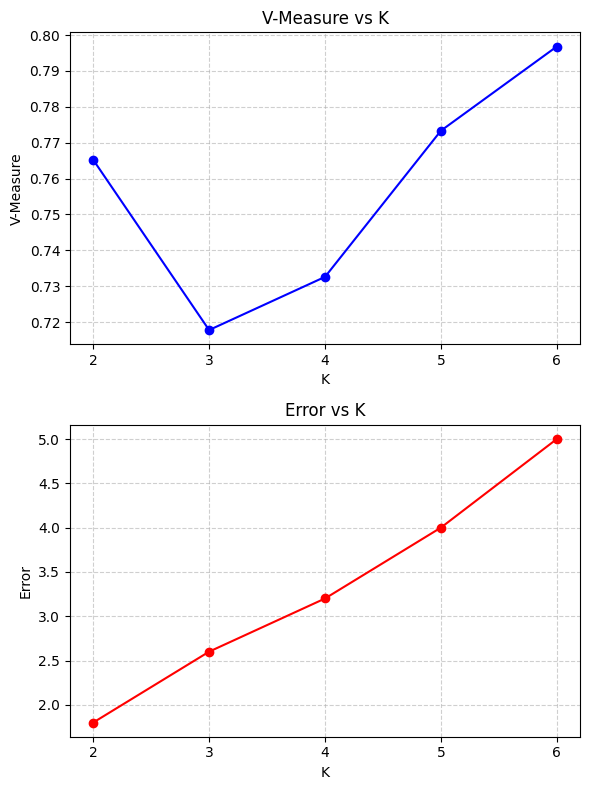

In [ ]:
# All Label
device_labels = ["GooglePixel3A_V", "HuaweiHonor9_R", "iPhone12_W", "SamsungM31_A", "SamsungS7_I", "XiaomiRedmiNote9S_T"]
# K Range
K_values = range(2, 6)
# average
avg_v_measures = []
avg_errors = []

# K = 2 to K = 5
for K in K_values:
    v_measure_list = []
    error_list = []

    for i in range(5):  # 5 times
        # random selected
        selected_labels = random.sample(device_labels, K)
        burst_df_k = burst_df_2[burst_df_2["Label"].isin(selected_labels)]
        # start
        clustered_df_k, num_clusters_k = assign_clusters(burst_df_k, 6)
        # v-measure
        v_measure_k = homogeneity_completeness_v_measure(clustered_df_k["Label"], clustered_df_k["Cluster ID"])[2]
        v_measure_list.append(v_measure_k)
        # error
        error_k = abs(len(clustered_df_k["Cluster ID"].unique()) - len(clustered_df_k["Label"].unique()))
        error_list.append(error_k)
        print(f"Iteration {i + 1}")
        print(f"V-Measure: {v_measure_k}")
        print(f"Error: {error_k}")

    # mean value
    avg_v_measures.append(np.mean(v_measure_list))
    avg_errors.append(np.mean(error_list))
    print(f"K = {K}")
    print(f"Average V-Measure: {avg_v_measures[-1]}")
    print(f"Average Error: {avg_errors[-1]}")

# K = 6
clustered_df_2, num_clusters_2 = assign_clusters(burst_df_2, 6)
v_measure_2 = homogeneity_completeness_v_measure(clustered_df_2["Label"], clustered_df_2["Cluster ID"])[2]
error_2 = abs(len(clustered_df_2["Cluster ID"].unique()) - len(clustered_df_2["Label"].unique()))
avg_v_measures.append(v_measure_2)
avg_errors.append(error_2)
print(f"K = {6}")
print(f"Average V-Measure: {v_measure_2}")
print(f"Average Error: {error_2}")

# Plot
K_values = list(K_values) + [6]
plt.figure(figsize=(6, 8))

# V-Measure
plt.subplot(2, 1, 1)
plt.plot(K_values, avg_v_measures, marker='o', linestyle='-', color='blue')
plt.xticks(K_values)
plt.xlabel("K")
plt.ylabel("V-Measure")
plt.title("V-Measure vs K")
plt.grid(True, linestyle='--', alpha=0.6)

# Error
plt.subplot(2, 1, 2)
plt.plot(K_values, avg_errors, marker='o', linestyle='-', color='red')
plt.xticks(K_values)
plt.xlabel("K")
plt.ylabel("Error")
plt.title("Error vs K")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [10]:
# unlabeled dataset
def assign_clusters_unlabeled(burst_df, N):

    label_cluster = []
    cluster_count = 0
    cluster_map = {}

    feature_columns = [
        "HT Capabilities", "Extended Capabilities",
        "Vendor Specific Tags", "Supported Rates", "Length", "Extended Supported Rates"
    ]

    for index, row in burst_df.iterrows():
        best_match_idx = None
        best_match_count = 0

        for prev_idx, prev_row in cluster_map.items():
            match_count = sum(row[feature] == prev_row[feature] for feature in feature_columns)

            if match_count > best_match_count:
                best_match_count = match_count
                best_match_idx = prev_idx
        if best_match_count >= N and best_match_idx is not None:
            cluster_id = label_cluster[best_match_idx][1]
        else:
            cluster_id = cluster_count
            cluster_count += 1

        label_cluster.append((index, cluster_id))
        cluster_map[index] = row

    df_result = pd.DataFrame(label_cluster, columns=["Index", "Cluster ID"])
    num_clusters = df_result["Cluster ID"].nunique()
    return df_result, num_clusters

# main
base_file = "/content/drive/MyDrive/captures/MAC_derand_unlabelled-challenge.csv"
df_3 = pd.read_csv(base_file)

nan_sum = df_3.isna().sum()
nan_percentage = (nan_sum / len(df_3)) * 100
print(nan_percentage)

df_preprocessed_3 = preprocess_data(df_3)
unique_elem = df_preprocessed.nunique()

selected_features_3 = select_features(df_preprocessed_3)
df_encoded_3 = encode_features(df_preprocessed_3, selected_features_3)
burst_df_3 = df_encoded_3.drop(columns=["Timestamp"])
burst_df_3 = burst_df_3.groupby("MAC Address").first().reset_index()

display(burst_df_3)

clustered_df_3, num_clusters_3 = assign_clusters_unlabeled(burst_df_3, 6)
print(f"Number of clusters: {num_clusters_3}")

Timestamp                    0.000000
MAC Address                  0.000000
Channel                      0.000000
DS Channel                   0.004887
HT Capabilities              0.000000
Extended Capabilities        0.000000
Vendor Specific Tags        14.835809
SSID                        95.431001
Supported Rates              0.000000
Extended Supported Rates     0.000000
VHT Capabilities            87.260555
HE Capabilities             76.324277
Length                       0.000000
dtype: float64
['SSID', 'VHT Capabilities', 'HE Capabilities']
['Channel', 'DS Channel', 'HT Capabilities', 'Extended Capabilities', 'Vendor Specific Tags', 'Supported Rates', 'Extended Supported Rates', 'Length']


,MAC Address,Channel,DS Channel,HT Capabilities,Extended Capabilities,Vendor Specific Tags,Supported Rates,Extended Supported Rates,Length
0,02:02:70:30:b6:43,1,3.0,2.0,1.0,6.0,2.0,0.0,143
1,02:0b:5b:9e:41:54,1,2.0,4.0,2.0,3.0,0.0,0.0,154
2,02:0b:72:cb:7d:eb,11,9.0,4.0,2.0,3.0,0.0,0.0,154
3,02:0c:01:7e:50:d6,11,13.0,4.0,2.0,3.0,0.0,0.0,154
4,02:11:33:61:b5:ef,1,2.0,2.0,1.0,6.0,2.0,0.0,143
...,...,...,...,...,...,...,...,...,...
1496,fe:c5:50:16:eb:8c,11,11.0,2.0,1.0,6.0,2.0,0.0,131
1497,fe:ed:a5:45:e8:b9,11,11.0,5.0,5.0,1.0,0.0,0.0,143
1498,fe:f5:97:dd:58:86,6,8.0,2.0,1.0,6.0,2.0,0.0,143
1499,fe:f9:ac:47:0d:b7,11,11.0,2.0,1.0,6.0,2.0,0.0,131


Number of clusters: 15


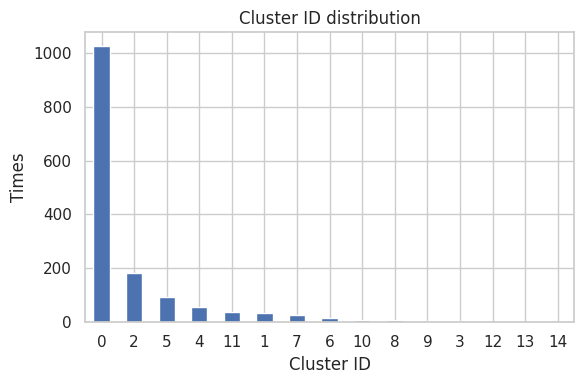

In [17]:
# Plot number of clusters
cluster_counts = clustered_df_3["Cluster ID"].value_counts()

plt.figure(figsize=(6, 4))
cluster_counts.plot(kind='bar')
plt.title('Cluster ID distribution')
plt.xlabel('Cluster ID')
plt.ylabel('Times')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# to csv
clustered_df_3 = clustered_df_3.set_index("Index")
merged_df = burst_df_3.copy()
merged_df["Cluster ID"] = clustered_df_3["Cluster ID"]

merged_df.to_csv("point3_result.csv", index=False)